# Iris Flower Classification
**Oasis Infobyte, Data Science, Task 1**

Predict **setosa**, **versicolor** or **virginica** from four flower measurements in centimetres.
The workflow uses scikit-learn's built-in Iris dataset, explores the features, and compares
Logistic Regression with K-Nearest Neighbours (KNN).


## 1. Import libraries

In [11]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from sklearn.base import clone
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedGroupKFold, cross_validate
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

SEED = 42
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 10)
pd.set_option("display.precision", 4)

## 2. Exploratory Data Analysis (EDA): Dataset Inspection
Each row is a flower. The predictors are sepal length, sepal width, petal length and
petal width; the target is species. Check shape, types, missing values, descriptive
statistics, class balance and repeated measurements.

In [12]:
iris = load_iris(as_frame=True)
X, y = iris.data.copy(), iris.target.copy()
features = X.columns.tolist()
species = iris.target_names.tolist()
labels = list(range(len(species)))
names = dict(enumerate(species))
data = X.assign(species=y.map(names))

print(f"Shape: {data.shape} — {X.shape[1]} predictors and one species column")
display(data.head())
display(pd.DataFrame({"dtype": data.dtypes.astype(str), "missing": data.isna().sum()}))
display(X.describe().T)
display(data["species"].value_counts().reindex(species).rename("count").to_frame())
print("Additional repeated rows:", data.duplicated().sum())_
display(data.loc[data.duplicated(keep=False)])

assert X.shape == (150, 4) and not data.isna().any().any()
assert np.isfinite(X.to_numpy()).all()

Shape: (150, 5) — 4 predictors and one species column


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


,dtype,missing
sepal length (cm),float64,0
sepal width (cm),float64,0
petal length (cm),float64,0
petal width (cm),float64,0
species,str,0


,count,mean,std,min,25%,50%,75%,max
sepal length (cm),150.0,5.8433,0.8281,4.3,5.1,5.80,6.4,7.9
sepal width (cm),150.0,3.0573,0.4359,2.0,2.8,3.00,3.3,4.4
petal length (cm),150.0,3.7580,1.7653,1.0,1.6,4.35,5.1,6.9
petal width (cm),150.0,1.1993,0.7622,0.1,0.3,1.30,1.8,2.5


,count
species,
setosa,50
versicolor,50
virginica,50


Additional repeated rows: 1


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
101,5.8,2.7,5.1,1.9,virginica
142,5.8,2.7,5.1,1.9,virginica


There are **150 flowers**, with **50 per species** and no missing values. 

## 3. 80/20 training/test split
Stratification preserves class proportions. Reserve the test set before examining
feature relationships or comparing models. All subsequent exploratory plots use
the training data.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

# Group identical feature vectors 
groups = pd.Series(pd.factorize(pd.MultiIndex.from_frame(X))[0], index=X.index)
train_groups = groups.loc[X_train.index]
assert set(X_train.index).isdisjoint(X_test.index)
assert set(train_groups).isdisjoint(groups.loc[X_test.index])

split_counts = pd.DataFrame({
    "Train": y_train.value_counts().sort_index(),
    "Test": y_test.value_counts().sort_index(),
}).rename(index=names)
display(split_counts)
print(f"Training: {len(X_train)} flowers; test: {len(X_test)} flowers")

,Train,Test
target,,
setosa,40,10
versicolor,40,10
virginica,40,10


Training: 120 flowers; test: 30 flowers


## 4. Feature relationships and distributions
The pairplot shows relationships between measurements, coloured by species. The box
plots compare every feature across the three species.

C:\Users\88019\anaconda3\Lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


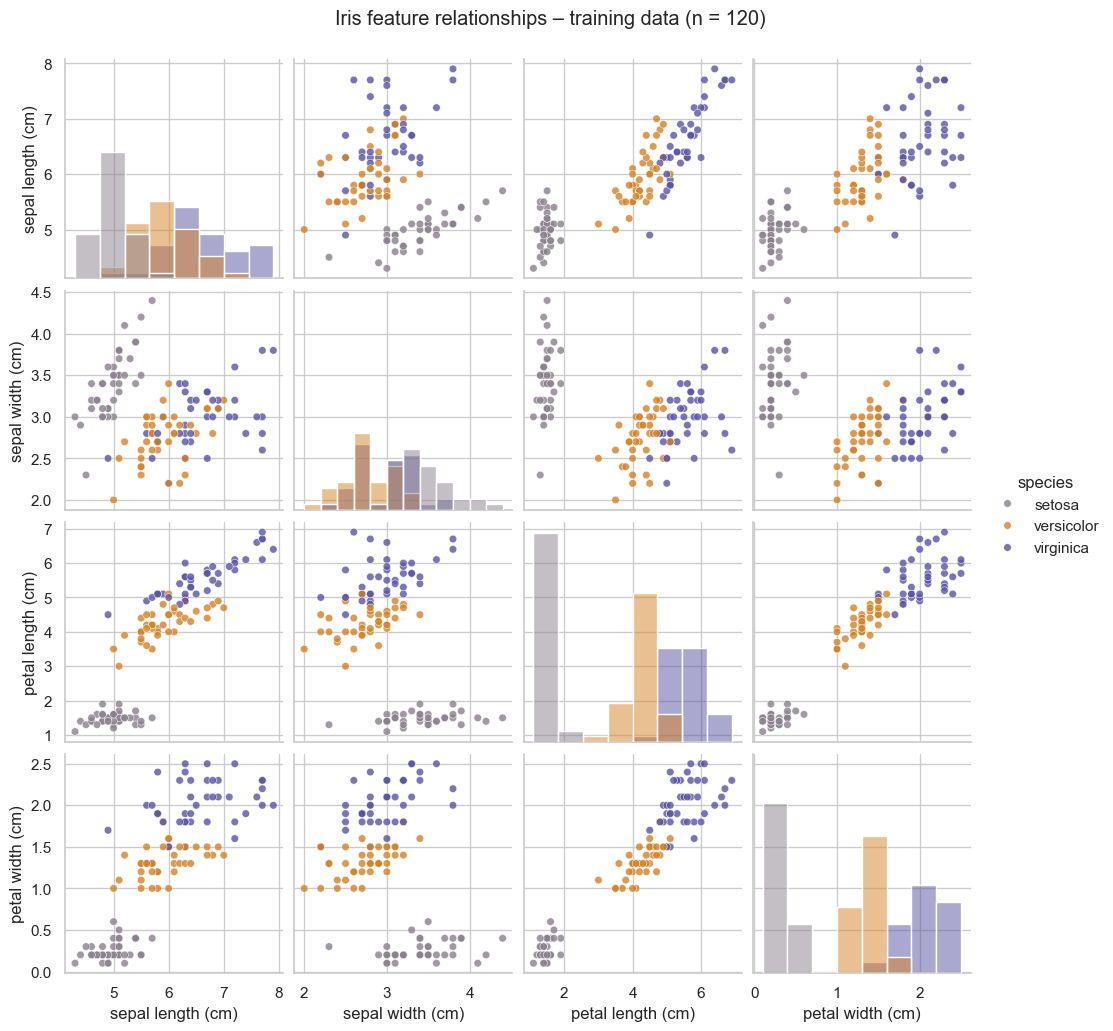

C:\Users\88019\AppData\Local\Temp\ipykernel_13240\3859045471.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\88019\AppData\Local\Temp\ipykernel_13240\3859045471.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\88019\AppData\Local\Temp\ipykernel_13240\3859045471.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\88019\AppData\Local\Temp\ipykernel_13240\3859045471.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `h

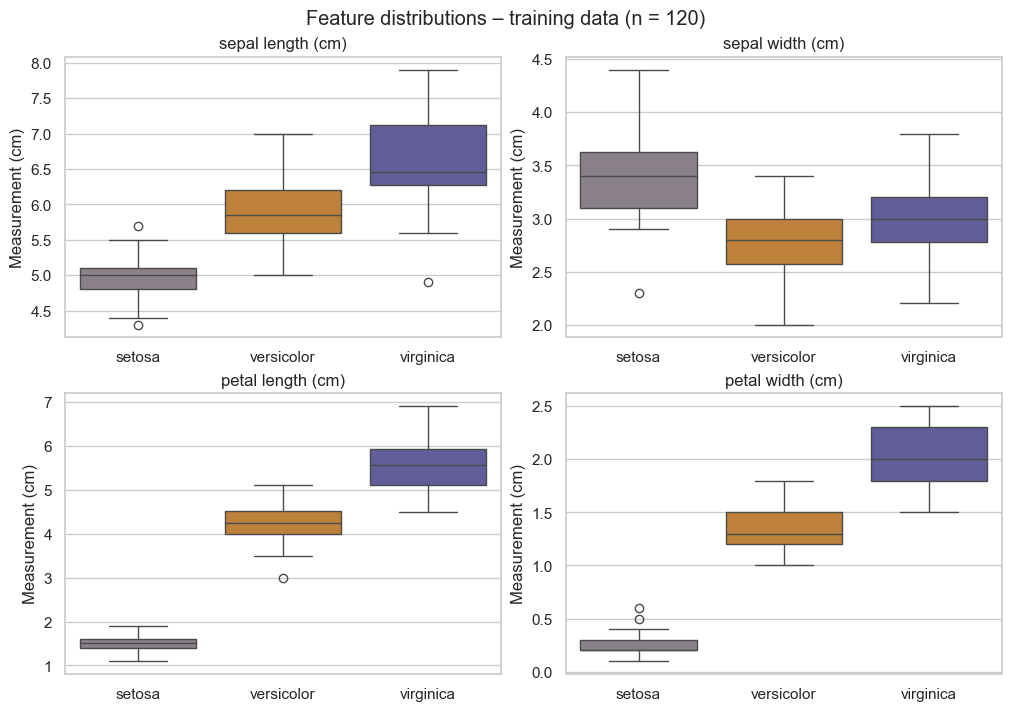

In [14]:
# path
output_dir = Path("outputs/figures")
output_dir.mkdir(parents=True, exist_ok=True)


# 1. Pairplot


train_data = X_train.assign(species=y_train.map(names))

palette = dict(zip(species, ["#8B7F8D", "#D48225", "#5953A3"]))

grid = sns.pairplot(
    train_data,
    vars=features,
    hue="species",
    palette=palette,
    diag_kind="hist",
    hue_order=species,
    plot_kws={"alpha": 0.8, "s": 30}
)

grid.figure.suptitle(
    "Iris feature relationships – training data (n = 120)",
    y=1.03
)

# Save pairplot
grid.figure.savefig(
    output_dir / "iris_feature_relationships_pairplot.png",
    dpi=160,
    bbox_inches="tight"
)

plt.show()
plt.close(grid.figure)


# 2. Boxplots


fig, axes = plt.subplots(
    2, 2,
    figsize=(10, 7),
    constrained_layout=True
)

for ax, feature in zip(axes.flat, features):
    sns.boxplot(
        data=train_data,
        x="species",
        y=feature,
        order=species,
        palette=palette,
        legend=False,
        ax=ax
    )

    ax.set_title(feature)
    ax.set_xlabel("")
    ax.set_ylabel("Measurement (cm)")

fig.suptitle(
    "Feature distributions – training data (n = 120)"
)

# Save boxplots
fig.savefig(
    output_dir / "iris_feature_distributions_boxplots.png",
    dpi=160,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

**Observations and feature choice:**
- Setosa has distinctly shorter, narrower petals. Versicolor and virginica overlap more.
- Petal length and petal width distinguish species more clearly than sepal width.
- Petal length and width are positively associated, so they contain overlapping information.


## 5. Define and compare two classifiers
**Logistic Regression** fits linear decision boundaries; **KNN** predicts from the five
nearest training examples. Both pipelines standardise features using training data only.

In [15]:
models = {
    "Logistic Regression": make_pipeline(
        StandardScaler(), LogisticRegression(C=1.0, solver="lbfgs", max_iter=2000)
    ),
    "KNN": make_pipeline(
        StandardScaler(), KNeighborsClassifier(n_neighbors=5, weights="uniform", p=2)
    ),
}

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
folds = list(cv.split(X_train, y_train, groups=train_groups))
for fit_idx, valid_idx in folds:
    assert set(train_groups.iloc[fit_idx]).isdisjoint(train_groups.iloc[valid_idx])

validation_rows = []
for name, model in models.items():
    scores = cross_validate(
        model, X_train, y_train, cv=folds,
        scoring={"accuracy": "accuracy", "macro_f1": "f1_macro"},
        n_jobs=1, error_score="raise",
    )
    validation_rows.append({
        "Model": name,
        "CV accuracy": scores["test_accuracy"].mean(),
        "CV accuracy SD": scores["test_accuracy"].std(ddof=1),
        "CV macro F1": scores["test_macro_f1"].mean(),
    })

validation = pd.DataFrame(validation_rows).set_index("Model")
priority = {"Logistic Regression": 0, "KNN": 1}
ranked = validation.assign(priority=validation.index.map(priority)).sort_values(
    ["CV accuracy", "CV macro F1", "priority"], ascending=[False, False, True]
)
selected_name = ranked.index[0]
display(validation)
print("Selected before test evaluation:", selected_name)

,CV accuracy,CV accuracy SD,CV macro F1
Model,,,
Logistic Regression,0.9583,0.0295,0.9582
KNN,0.9500,0.0349,0.9494


Selected before test evaluation: Logistic Regression


Fold standard deviation describes variation across the five folds; it is not a
confidence interval. A small validation difference does not establish that one model
is generally superior.

## 6. Evaluating both models on the test set
Fit each pipeline on all 120 training flowers. Report accuracy, per-species precision,
recall and F1, and confusion matrices for the same 30 held-out flowers. Macro F1 gives
equal weight to each species.

In [16]:
predictions = {}
test_rows = []
for name, model in models.items():
    fitted = clone(model).fit(X_train, y_train)
    predicted = fitted.predict(X_test)
    predictions[name] = predicted
    print(f"\n{name}")
    print(classification_report(
        y_test, predicted, labels=labels, target_names=species,
        digits=4, zero_division=0,
    ))
    test_rows.append({
        "Model": name,
        "Test accuracy": accuracy_score(y_test, predicted),
        "Test macro F1": f1_score(y_test, predicted, average="macro"),
        "Correct / 30": int(np.sum(predicted == y_test.to_numpy())),
    })

test_results = pd.DataFrame(test_rows).set_index("Model")
comparison = validation[["CV accuracy"]].join(test_results)
display(comparison)


Logistic Regression
              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        10
  versicolor     0.9000    0.9000    0.9000        10
   virginica     0.9000    0.9000    0.9000        10

    accuracy                         0.9333        30
   macro avg     0.9333    0.9333    0.9333        30
weighted avg     0.9333    0.9333    0.9333        30


KNN
              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        10
  versicolor     0.8333    1.0000    0.9091        10
   virginica     1.0000    0.8000    0.8889        10

    accuracy                         0.9333        30
   macro avg     0.9444    0.9333    0.9327        30
weighted avg     0.9444    0.9333    0.9327        30



,CV accuracy,Test accuracy,Test macro F1,Correct / 30
Model,,,,
Logistic Regression,0.9583,0.9333,0.9333,28
KNN,0.9500,0.9333,0.9327,28


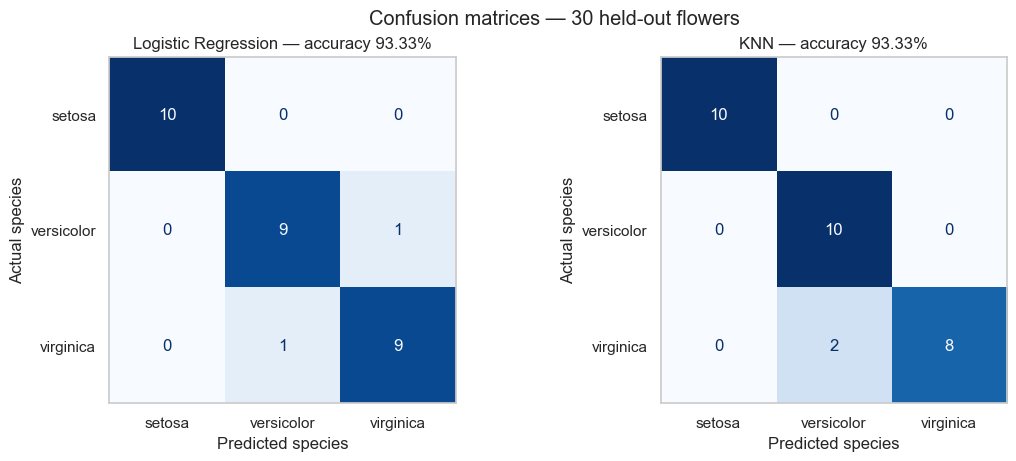

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)
for ax, (name, predicted) in zip(axes, predictions.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, predicted, labels=labels, display_labels=species,
        cmap="Blues", colorbar=False, values_format="d", ax=ax,
    )
    ax.grid(False)
    ax.set_title(f"{name} — accuracy {test_results.loc[name, 'Test accuracy']:.2%}")
    ax.set_xlabel("Predicted species")
    ax.set_ylabel("Actual species")
fig.suptitle("Confusion matrices — 30 held-out flowers")

# Save
output_dir = Path("outputs/figures")
output_dir.mkdir(parents=True, exist_ok=True)

fig.savefig(output_dir / "confusion_matrices.png", dpi=160, bbox_inches="tight")

**Error interpretation:** Logistic Regression misclassifies one versicolor as virginica
and one virginica as versicolor. KNN misclassifies two virginica flowers as versicolor.
Both identify all ten setosa flowers correctly, consistent with the clearer separation
of setosa in the training plots.

## 7. Conclusion and limitations

In [18]:
chosen = comparison.loc[selected_name]
display(Markdown(
    f"**Selected model: {selected_name}.** Its mean training cross-validation accuracy "
    f"is **{chosen['CV accuracy']:.2%}**. On the test set, it correctly classifies "
    f"**{int(chosen['Correct / 30'])}/30 flowers**, with **{chosen['Test accuracy']:.2%} "
    f"accuracy** and **{chosen['Test macro F1']:.4f} macro F1**."
))

**Selected model: Logistic Regression.** Its mean training cross-validation accuracy is **95.83%**. On the test set, it correctly classifies **28/30 flowers**, with **93.33% accuracy** and **0.9333 macro F1**.

Both models achieved **93.33% test accuracy**. Logistic Regression was selected using
the higher validation accuracy (**95.83% versus 95.00%**), rather than a test-accuracy
advantage. Petal measurements show the clearest species separation; all four inputs
remain in the models.

This small, balanced dataset contains only three species. One changed test prediction
changes accuracy by **3.33 percentage points**. The small model difference should not
be overinterpreted, and performance on other species or measurement conditions has
not been evaluated.

## 8. Sources and assistance
- Dataset: [scikit-learn — Iris dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html).
- Implementation guidance: [pipelines and data leakage](https://scikit-learn.org/stable/common_pitfalls.html),
  [cross-validation](https://scikit-learn.org/stable/modules/cross_validation.html), and
  [StratifiedGroupKFold](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedGroupKFold.html).
- Visualisation: [Seaborn pairplot](https://seaborn.pydata.org/generated/seaborn.pairplot.html).